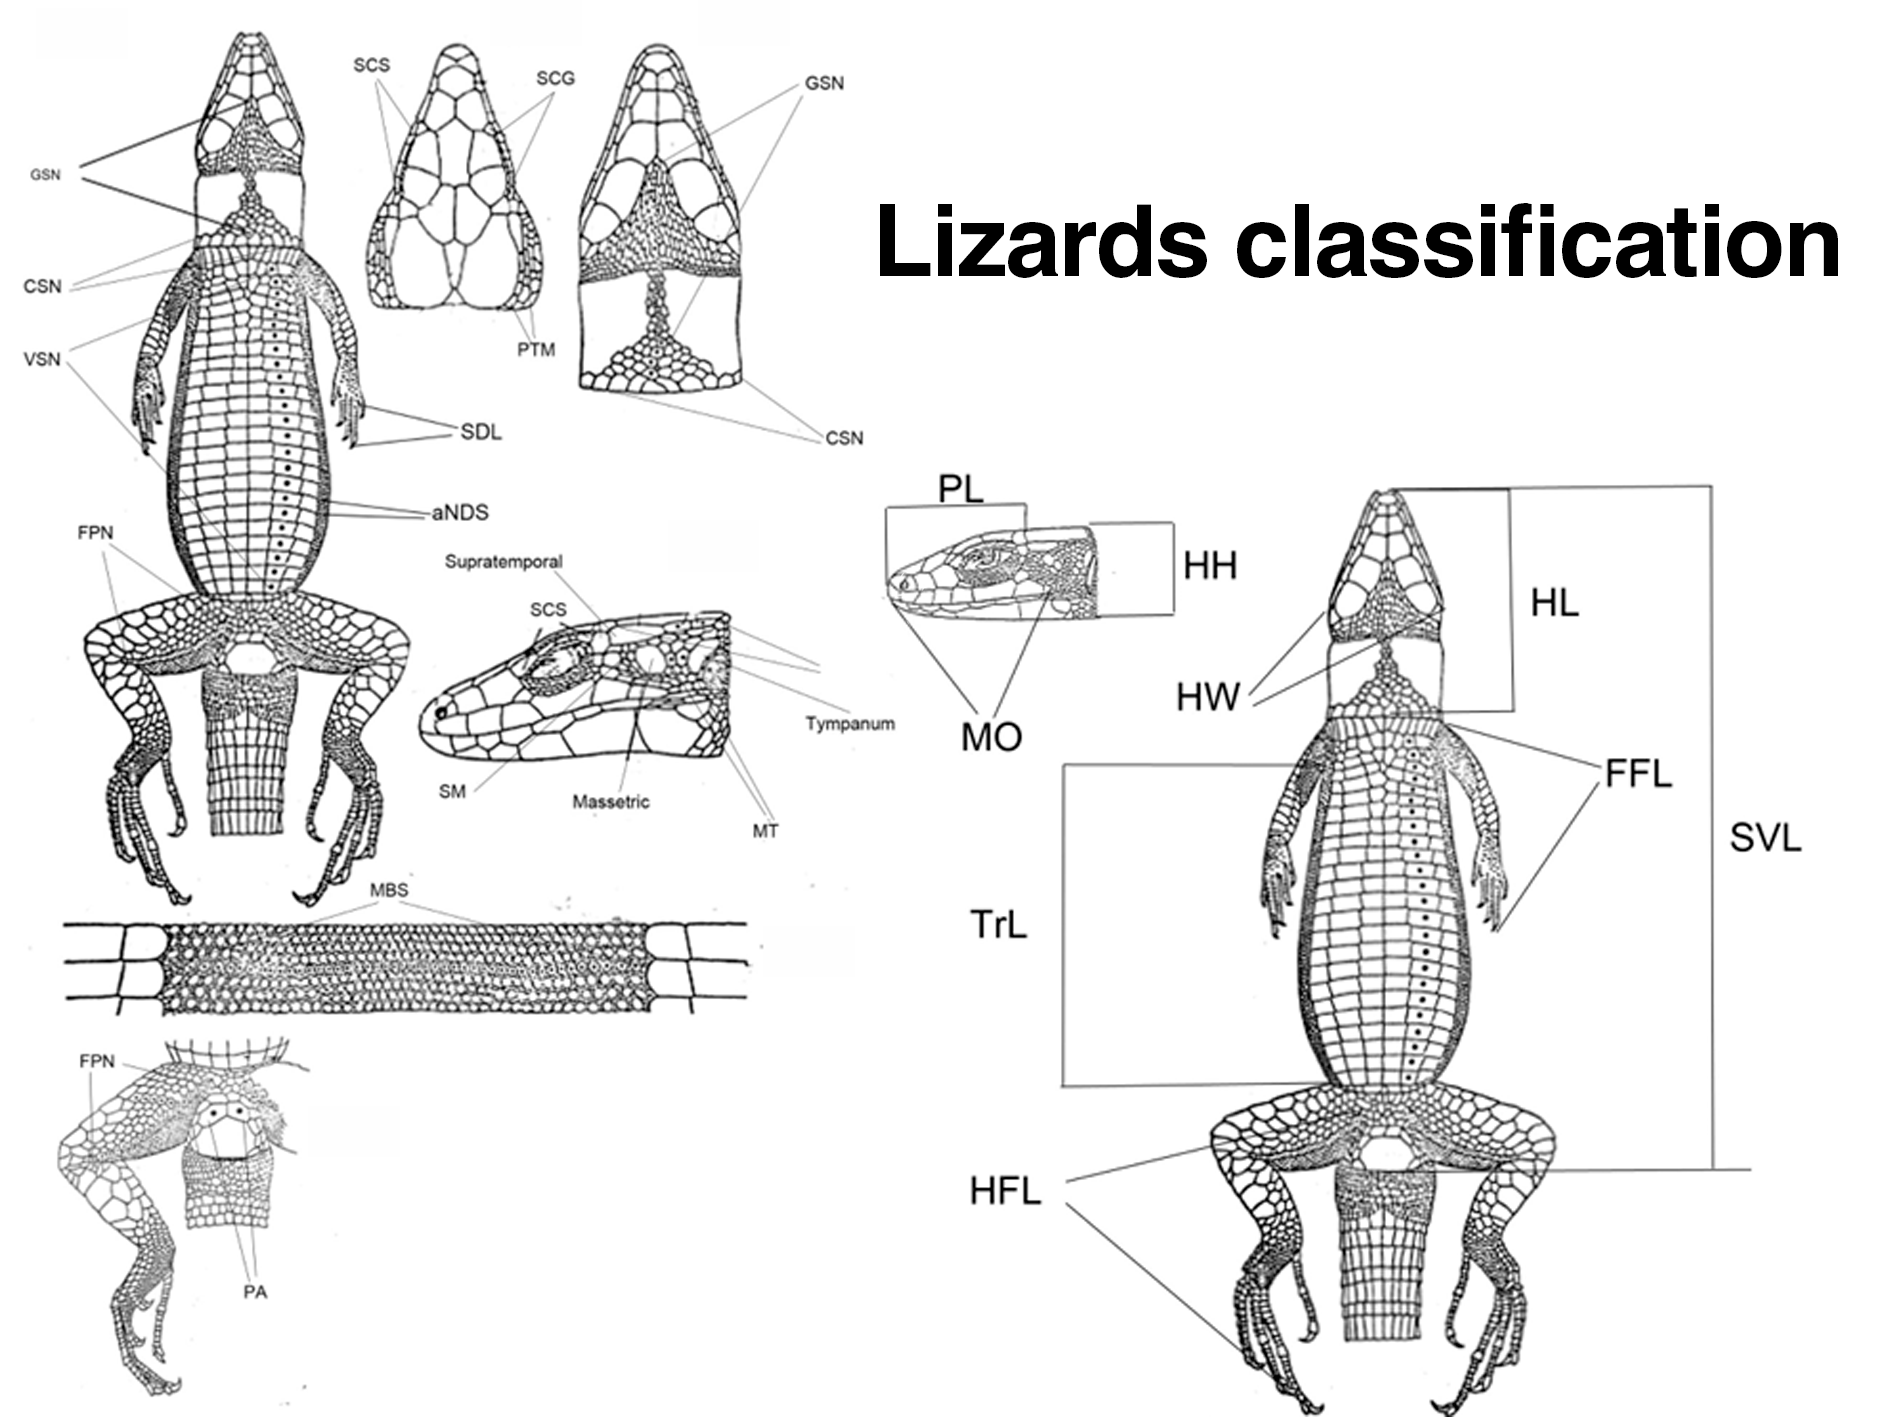

Data description


##### **Signs of folidosis (scale counting on the body):**
1. **MBS** - medium body scales, number of dorsal scales, approximately at half trunk
2. **VSN** - ventral scale number on the middle line
3. **CSN** - collar scale number
4. **GSN** - gular scale number from the angle between the maxillar scales to the collar
5. **FPN** - femoral pore number (FPNr – FPN справа / FPN on the right side)
6. **SDL** - subdigital lamellae in the 4th toe of the forelimb (SDL on the right forelimb)
7. **SCS** - number of superciliary scales (SCS on the right)
8. **SCG** - number of superciliary granules (SCG on the right)
9. **SM** - number of scales between the masseteric shield and the supratemporal scale (SM on the right)
10. **MT** - number of scales between masseteric and tympanum shields on the right (MT on the right)
11. **PA** - preanal scale number
12. **PTM** - postemporal scale number (PTM on the right)
13. **aNDS** – average number of dorsal scales along one abdomen scale near limb (aNDS on the right);
##### **Morphometric characteristics (all lengths are given in millimeters):**
14. **SVL** - snout-vent length, length of the body from tipof snout to cloaca
15. **TRL** - trunk length (from the groin to the armpit)
16. **HL** - head length, measured ventrally from the tip of the snout to the posterior margin of the collar
17. **PL** - pileus length measured dorsally from the tip of the snout to the posterior margin of the parietal + occipital scales
18. **ESD** - length of the posterior half of the pileus, measured from the anterior margin of the 3rd supraocular scale to the posterior margin of the parietal occipital scales
19. **HW** - width of the head before the tympanic hole
20. **HH** - head height near the occipital plate;
21. **MO** - mouth opening, measured laterally from the tip of the snout to the end of themouth
22. **FFL** - total forelimb length, from the base to the tip of the longest toe
23. **HFL** - total hindlimb length, from the base to the tip of the
longest toe.
#### Target variabels
**Sex_num** (2 total, varies from 1 to 2) | Sex (duplicates this param with string "M" and "F" respectively)

**Species_num** (8 total, varies from 1 to 8)

Imports and data loading

In [403]:
from typing import Literal

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

from config.config import DATA_PATH, DecisionTreeConfig, RANDOM_STATE

In [245]:
with open(DATA_PATH / "lizards_raw.csv", "r", encoding="utf-8") as f:
    df = pd.read_csv(f,sep=";")

Checking data types and looking for null

In [410]:
df.dtypes

Species_num      int64
Sex_num          int64
MBS              int64
VSN              int64
CSN              int64
GSN              int64
FPNr             int64
SDLr             int64
SCSr             int64
SCGr             int64
SMr              int64
MTr              int64
PA               int64
PTMr             int64
aNDSr          float64
SVL            float64
TRL            float64
HL             float64
PL             float64
ESD            float64
HW             float64
HH             float64
MO             float64
FFL            float64
HFL            float64
dtype: object

In [247]:
df.isna().sum()

Species_num    0
Sex_num        0
Sex            0
MBS            0
VSN            0
CSN            0
GSN            0
FPNr           0
SDLr           0
SCSr           0
SCGr           0
SMr            0
MTr            0
PA             0
PTMr           0
aNDSr          0
SVL            0
TRL            0
HL             0
PL             0
ESD            0
HW             0
HH             0
MO             0
FFL            0
HFL            0
dtype: int64

In [248]:
df.nunique()

Species_num      8
Sex_num          2
Sex              2
MBS             27
VSN             13
CSN             10
GSN             18
FPNr            17
SDLr            17
SCSr             7
SCGr            16
SMr              4
MTr              7
PA               3
PTMr             7
aNDSr           17
SVL            144
TRL            166
HL             104
PL              75
ESD             74
HW              61
HH              56
MO              74
FFL            120
HFL            148
dtype: int64

As can be seen where is no empty data (null), so we do not need to fill or somehow process it

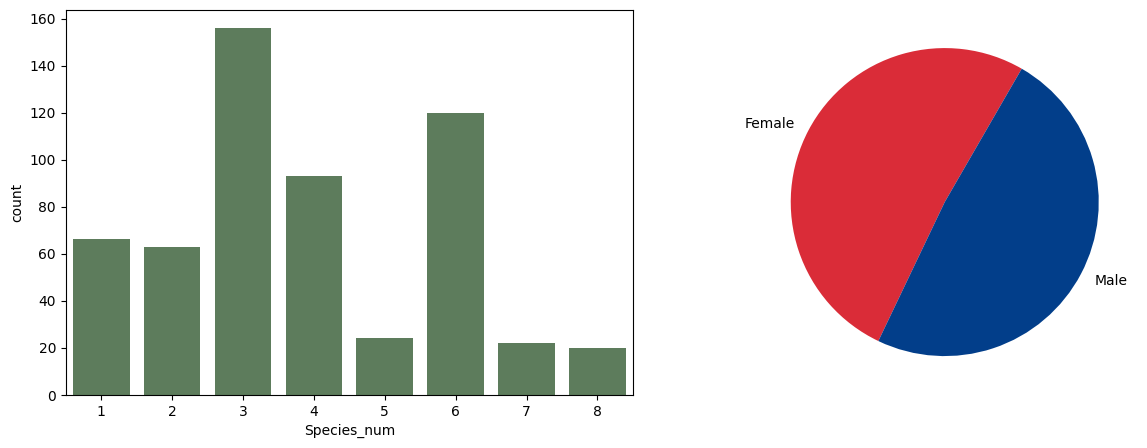

In [252]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

sns.countplot(
    x="Species_num",
    data=df,
    ax=ax1,
    color="#588157"
)
df["Sex"] = df["Sex"].replace({"M": "Male", "F": "Female"})
sex_df = df["Sex"].value_counts()
ax2.pie(
    sex_df,
    labels=sex_df.index,
    startangle = 60,
    colors = ["#DA2C38","#023e8a"]
)
plt.subplots_adjust(wspace=0.05)
plt.show()

<Axes: xlabel='Species_num', ylabel='count'>

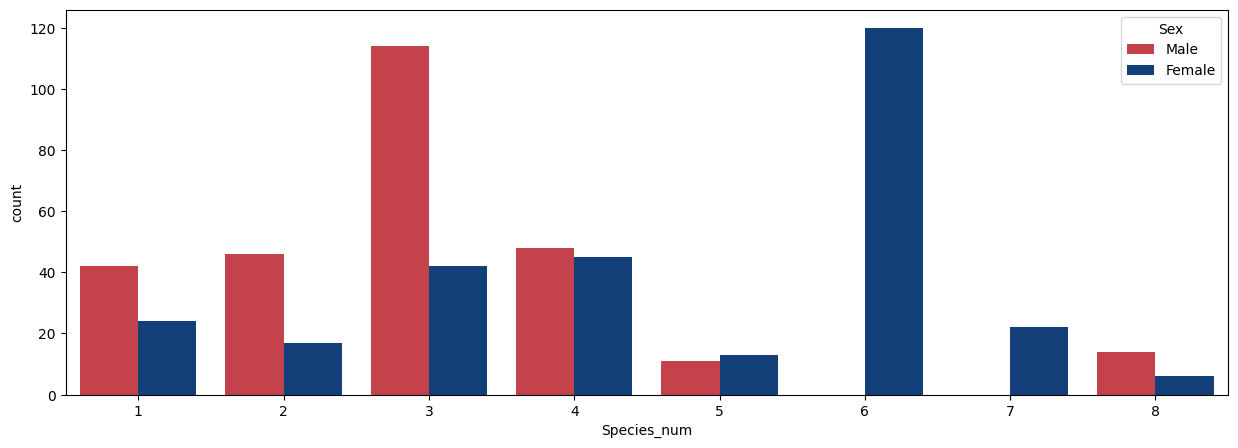

In [254]:
plt.figure(figsize=(15, 5))
sns.countplot(
    data=df,
    x="Species_num",
    hue="Sex",
    palette=["#DA2C38","#023e8a"]
)

In [259]:
df.drop(columns=["Sex"], inplace=True)

In [ ]:
def visualize_pca(
        data_df: pd.DataFrame,
        target_col: Literal["Species_num", "Sex_num"]) -> None:
    data_dropped = data_df.drop(columns=["Species_num", "Sex_num"])

    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_dropped)

    pca = PCA(n_components=3)
    data_pca = pca.fit_transform(data_scaled)
    variance_ratio = pca.explained_variance_ratio_

    data_plot = pd.DataFrame(data=data_pca, columns=["PC1", "PC2", "PC3"])
    data_plot[target_col] = data_df[target_col].astype(str).values
    if target_col == "Sex_num":
        data_plot[target_col] = data_plot[target_col].replace({"1": "Male", "2": "Female"})

    fig = plt.figure(figsize=(15, 5))
    ax1 = fig.add_subplot(1, 2, 2)
    ax2 = fig.add_subplot(1, 2, 1, projection="3d")

    sns.scatterplot(
        data=data_plot,
        x="PC1",
        y="PC2",
        hue=target_col,
        ax=ax1
    )
    ax1.set_title(f"Variance ratio {round(np.sum(variance_ratio[:2])*100)}%")

    scatter_plot = ax2.scatter3D(
        data_plot["PC1"],
        data_plot["PC2"],
        data_plot["PC3"],
        c=data_df[target_col].values
    )
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")
    ax2.set_title(f"Variance ratio {round(np.sum(variance_ratio)*100)}%")
    handles, labels = scatter_plot.legend_elements()
    if target_col == "Sex_num":
        labels = ["Male", "Female"]
    ax2.legend(handles, labels, title=target_col)

    plt.subplots_adjust(wspace=0.1)
    plt.show()

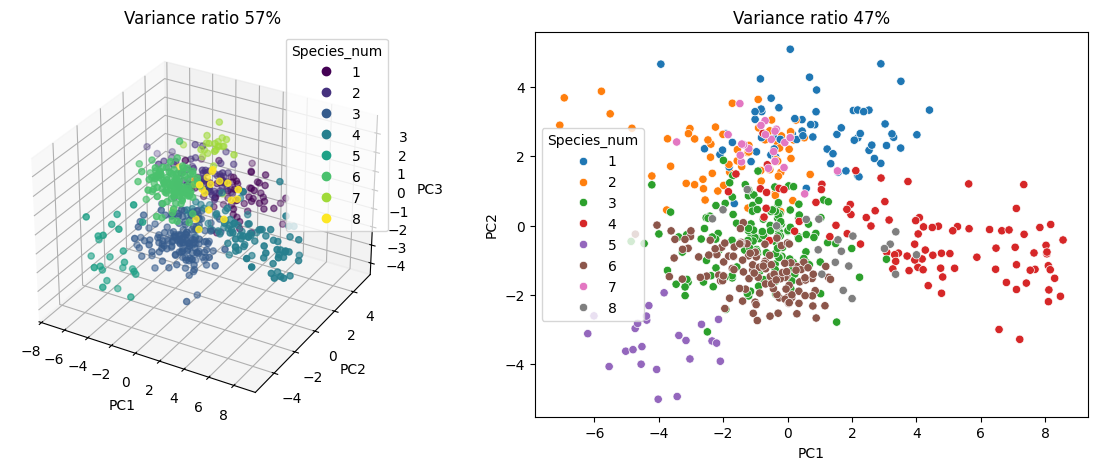

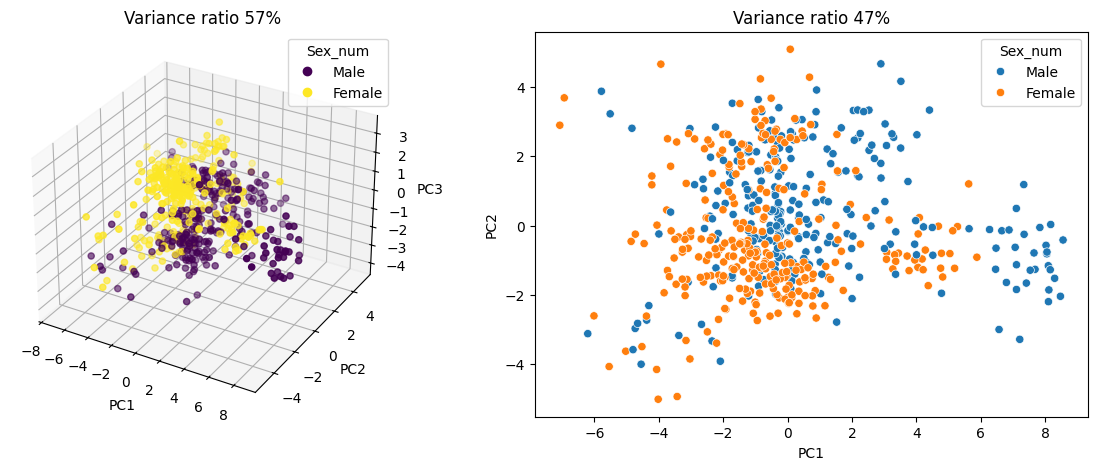

In [326]:
visualize_pca(df, "Species_num")
visualize_pca(df, "Sex_num")

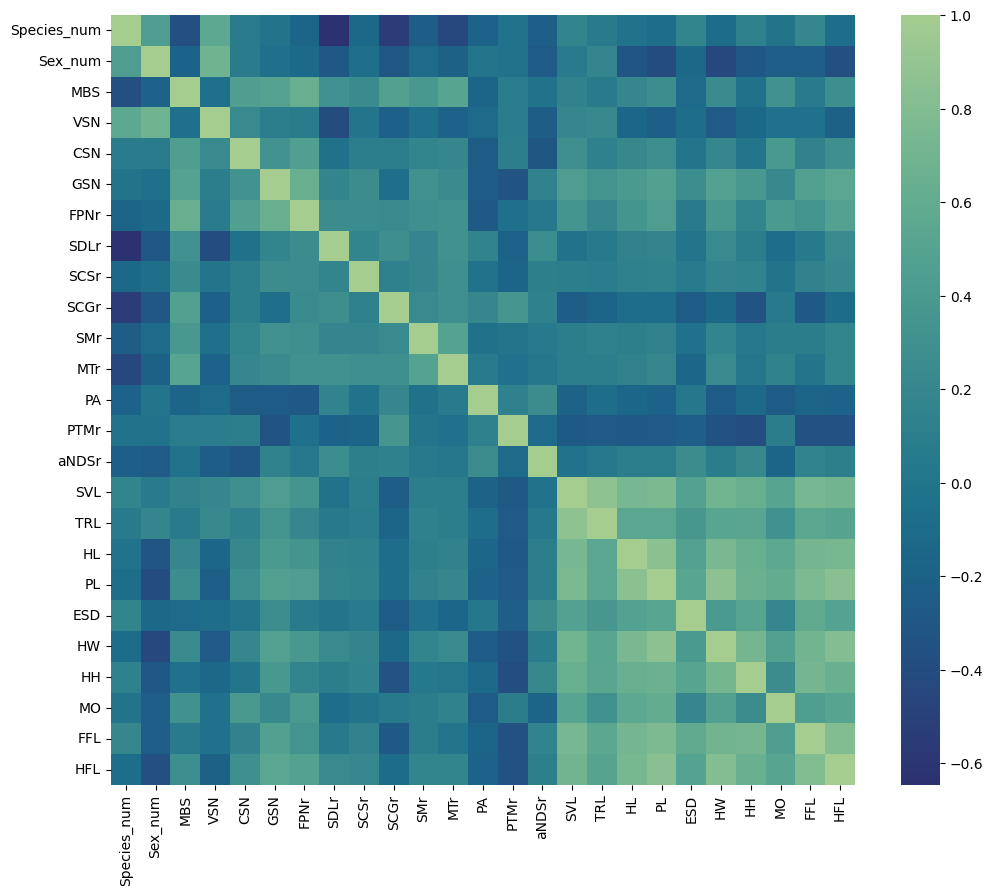

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    data=df.corr(),
    cmap="crest_r"
)
plt.show()

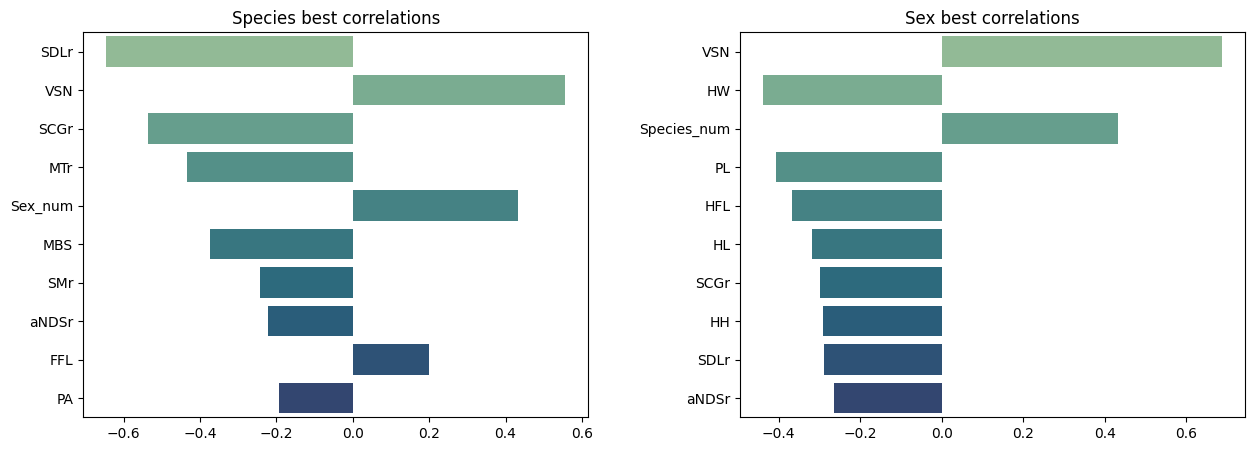

In [370]:
species_best_corr = df.corr()['Species_num'].sort_values(key=abs, ascending=False)[1:].head(10)
sex_best_corr = df.corr()["Sex_num"].sort_values(key=abs, ascending=False)[1:].head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
sns.barplot(
    x=species_best_corr.values,
    y=species_best_corr.index,
    ax=ax1,
    hue=species_best_corr.index,
    palette="crest"
)
ax1.set_title("Species best correlations")
ax1.set_ylabel("")

sns.barplot(
    x=sex_best_corr.values,
    y=sex_best_corr.index,
    ax=ax2,
    hue=sex_best_corr.index,
    palette="crest"
)
ax2.set_ylabel("")
ax2.set_title("Sex best correlations")
plt.subplots_adjust(wspace=0.3)
plt.show()

In [ ]:
X_species = df.drop(columns=["Species_num"])
y_species = df["Species_num"]
X_train_species, X_test_species, y_train_species, y_test_species = train_test_split(
    X_species,
    y_species,
    random_state=RANDOM_STATE,
    stratify=y_species
)

X_sex = df.drop(columns=["Sex_num"])
y_sex = df["Sex_num"]
X_train_sex, X_test_sex, y_train_sex, y_test_sex = train_test_split(
    X_sex,
    y_sex,
    random_state=RANDOM_STATE,
    stratify=y_sex
)

In [373]:
def train_tree_with_best_params(
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        ) -> GridSearchCV:
    param_grid = {
    "max_depth": list(range(3, 11)),
    "max_leaf_nodes": list(range(10, 26)),
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 4, 6, 8, 10, 12, 14, 16],
    }
    clf = DecisionTreeClassifier(**DecisionTreeConfig().params)
    clf = GridSearchCV(clf, param_grid)
    clf.fit(X_train, y_train)
    return clf

In [374]:
clf_sex = train_tree_with_best_params(X_train_sex, y_train_sex)
clf_species = train_tree_with_best_params(X_train_species, y_train_species)

In [400]:
y_pred_species = clf_species.predict(X_test_species)
y_pred_sex = clf_sex.predict(X_test_sex)

In [375]:
print(f"Species Acc: {clf_species.score(X_test_species, y_test_species):.3f} with following params:")
print(clf_species.best_params_)

print(f"\nSex Acc: {clf_sex.score(X_test_sex, y_test_sex):.3f} with following params:")
print(clf_species.best_params_)

Species Acc: 0.816 with following params:
{'criterion': 'entropy', 'max_depth': 7, 'max_leaf_nodes': 21, 'min_samples_split': 2}

Sex Acc: 0.858 with following params:
{'criterion': 'entropy', 'max_depth': 7, 'max_leaf_nodes': 21, 'min_samples_split': 2}


In [166]:
def show_tree(clf: GridSearchCV, X_train: pd.DataFrame) -> None:
    plt.figure(figsize=(30, 15))
    plot_tree(
        clf.best_estimator_,
        filled=True,
        rounded=True,
        feature_names=X_train.columns.to_list(),
        class_names= list(map(str, clf_species.classes_)),
        fontsize=10,
    )

    plt.show()

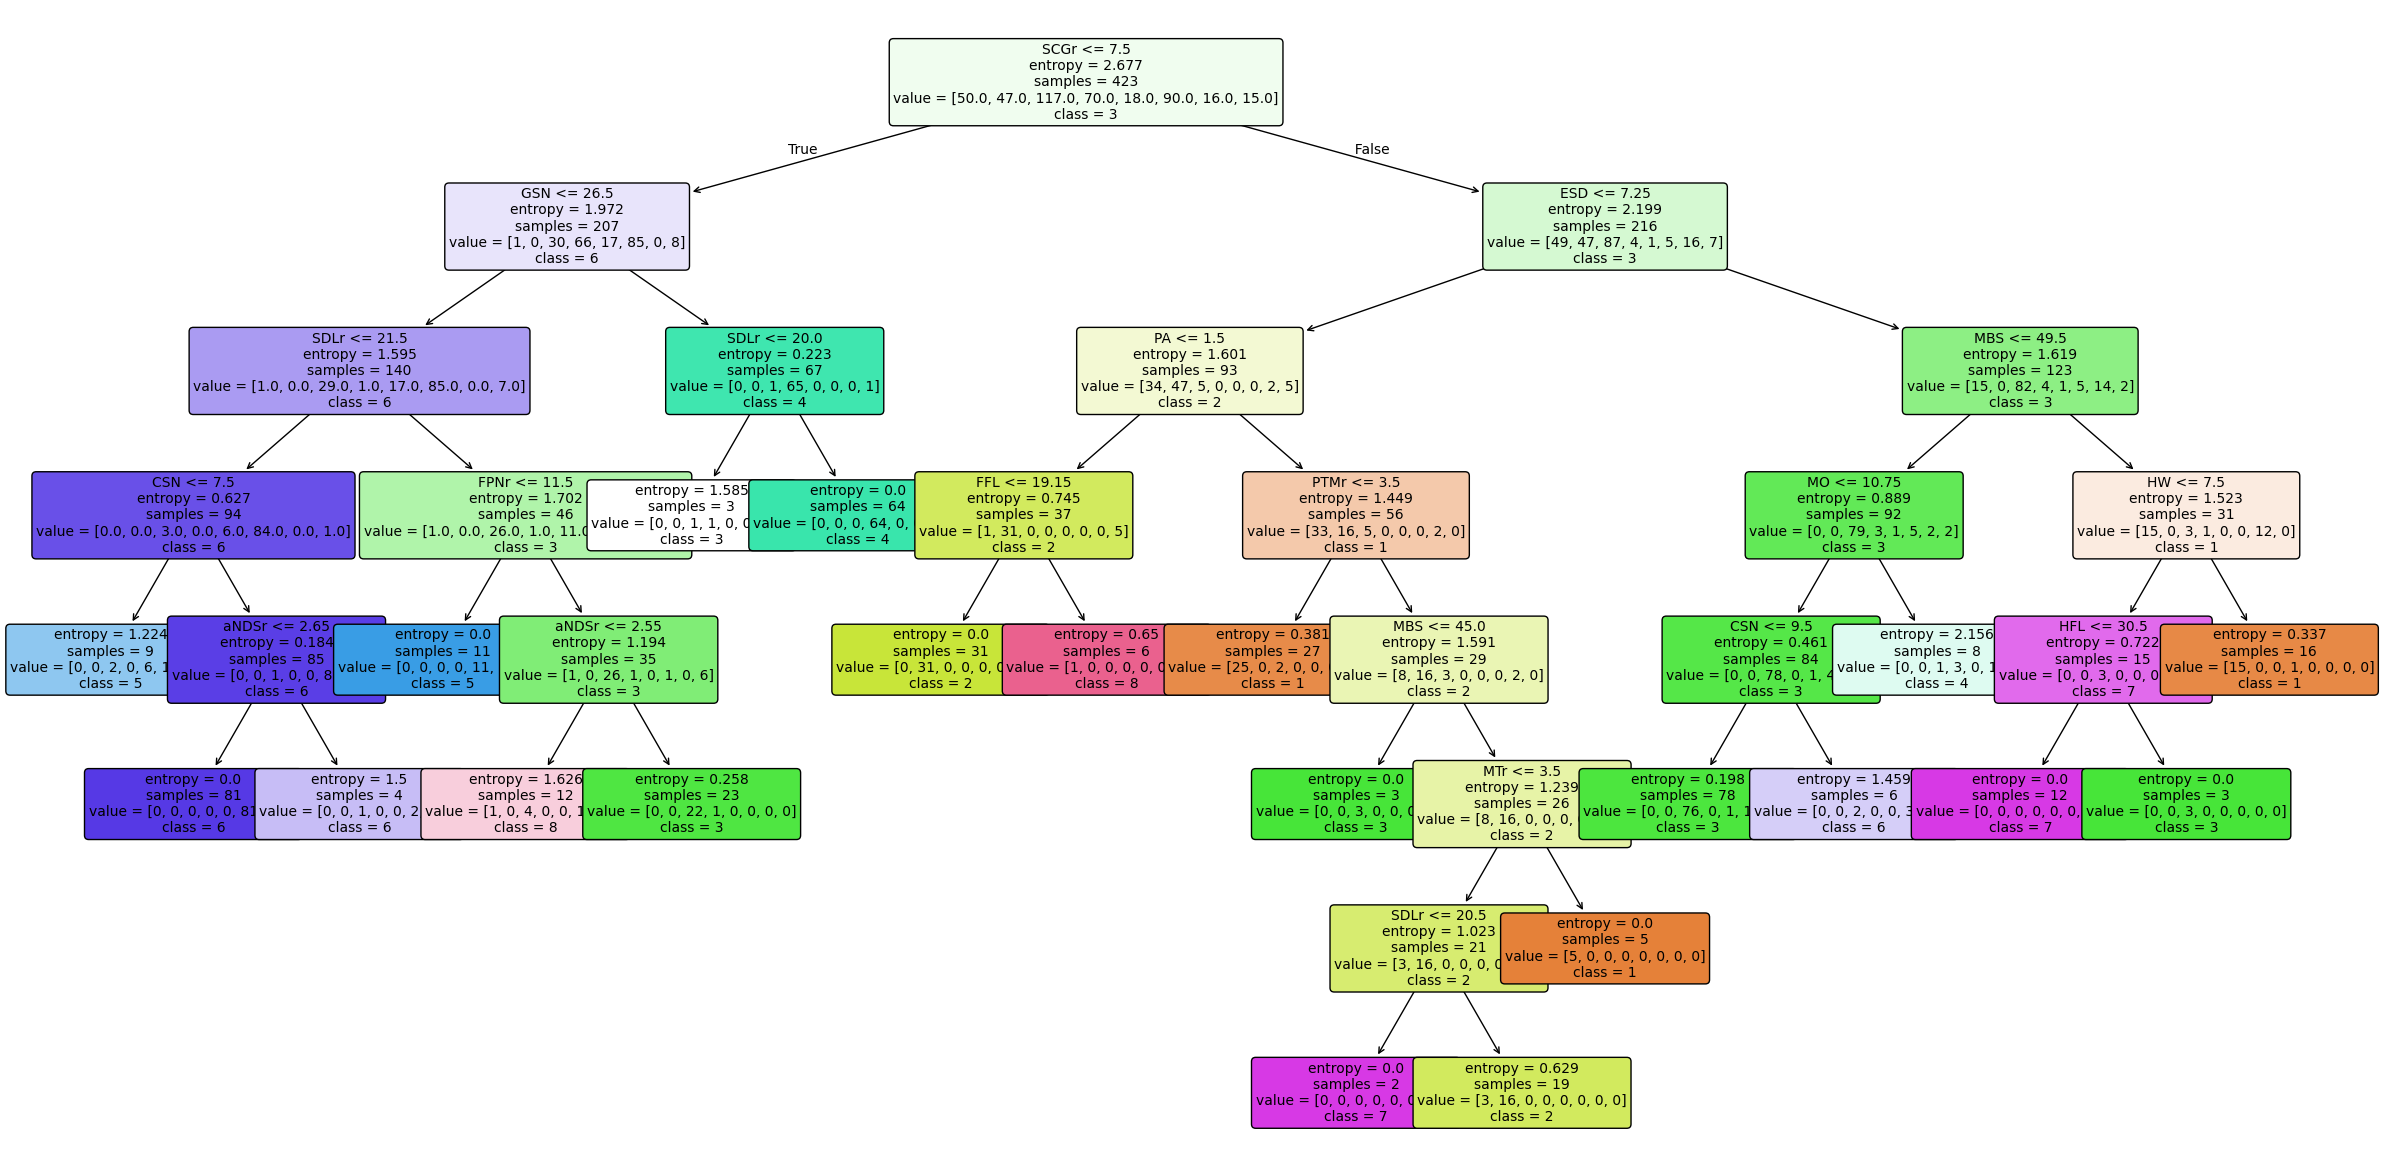

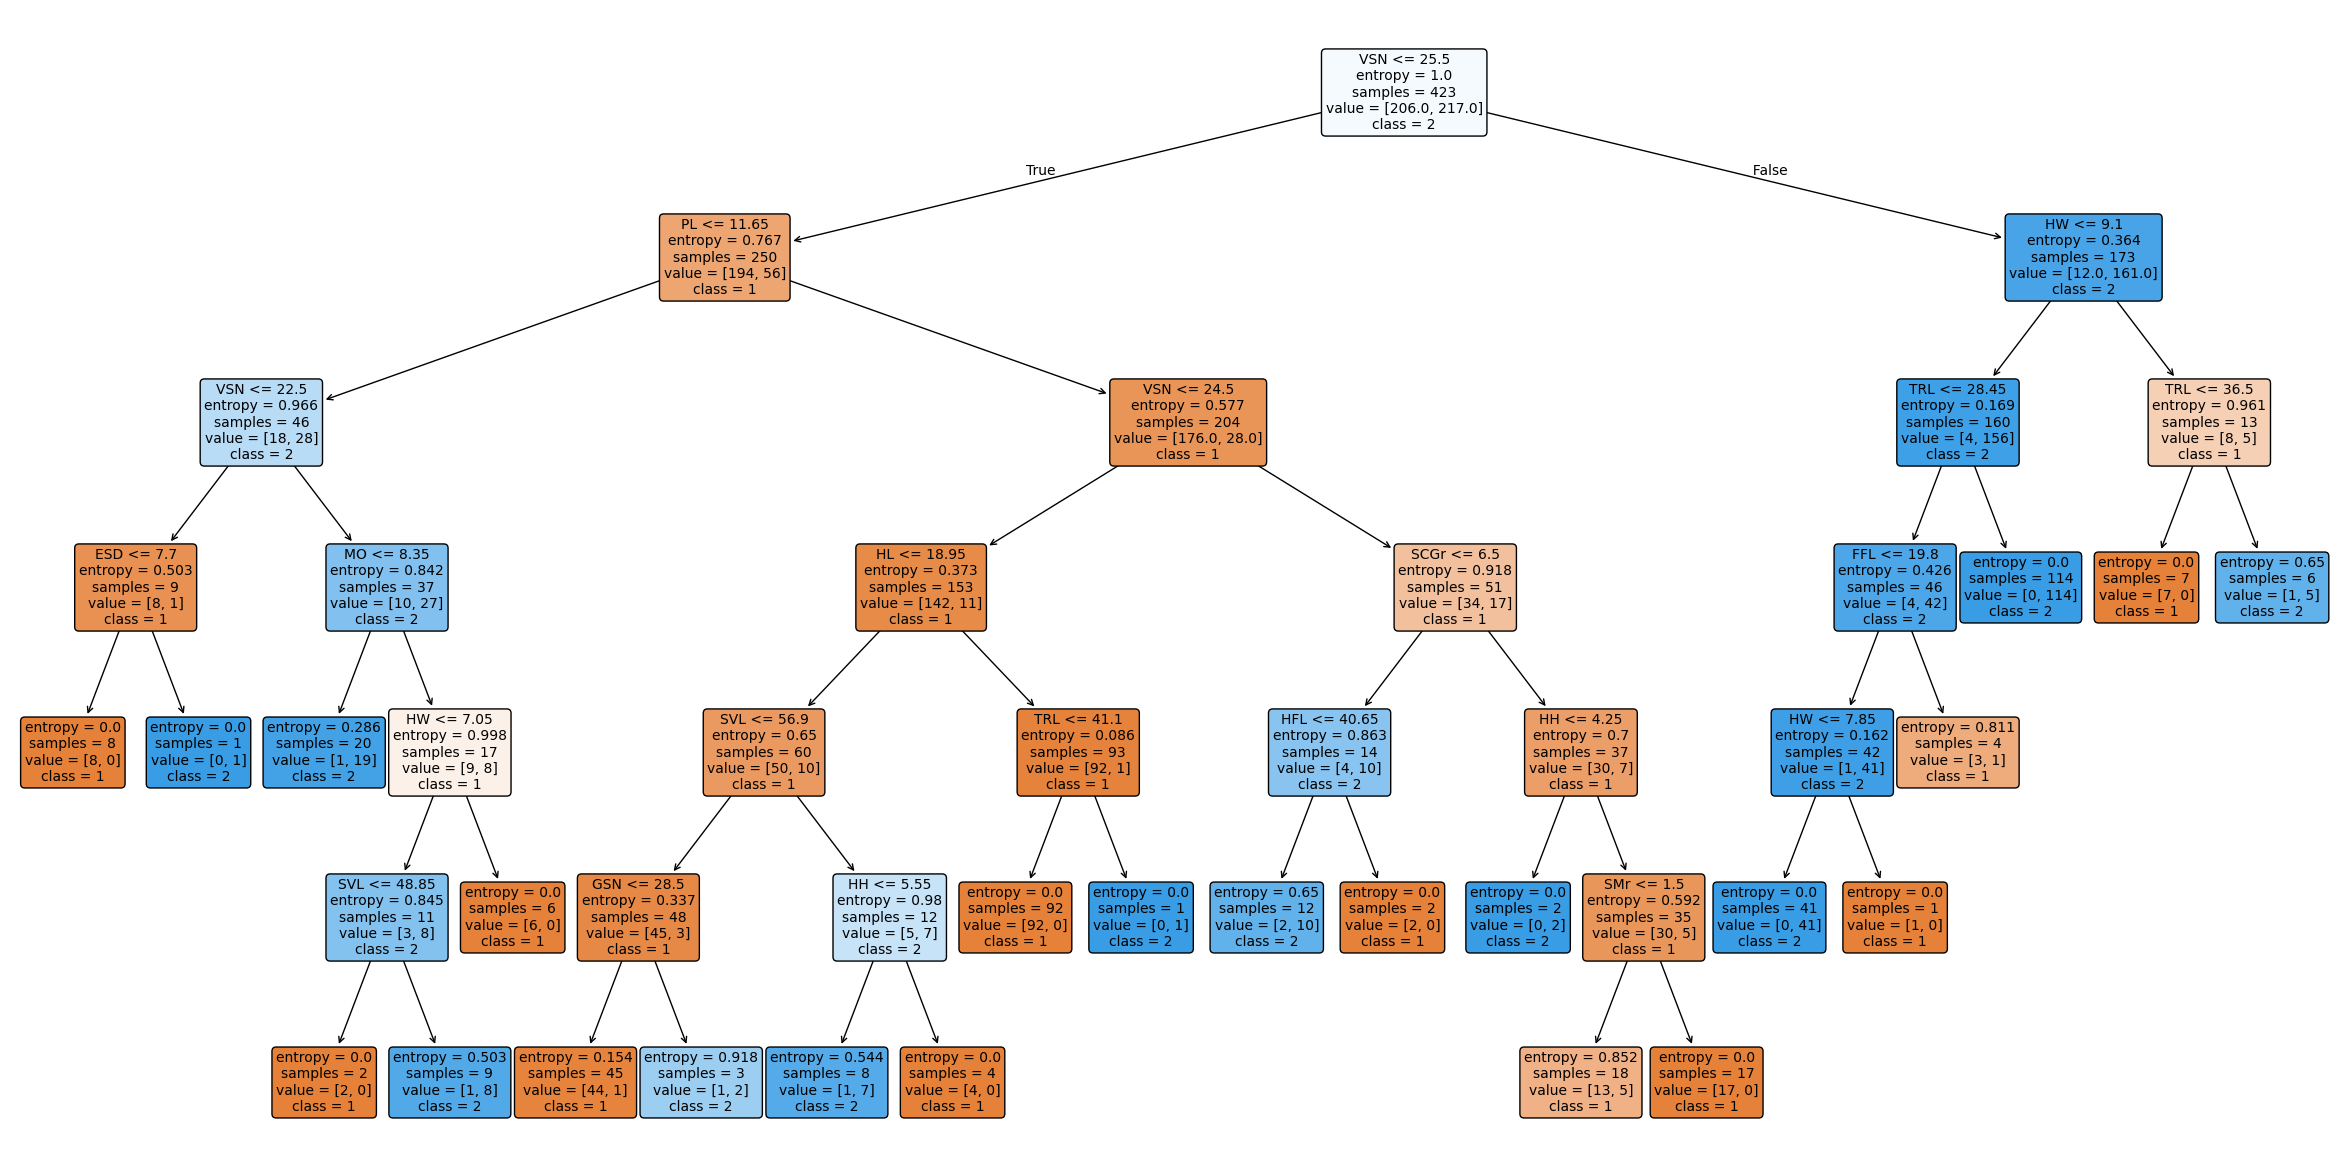

In [167]:
show_tree(clf_species, X_train_species)
show_tree(clf_sex, X_train_sex)

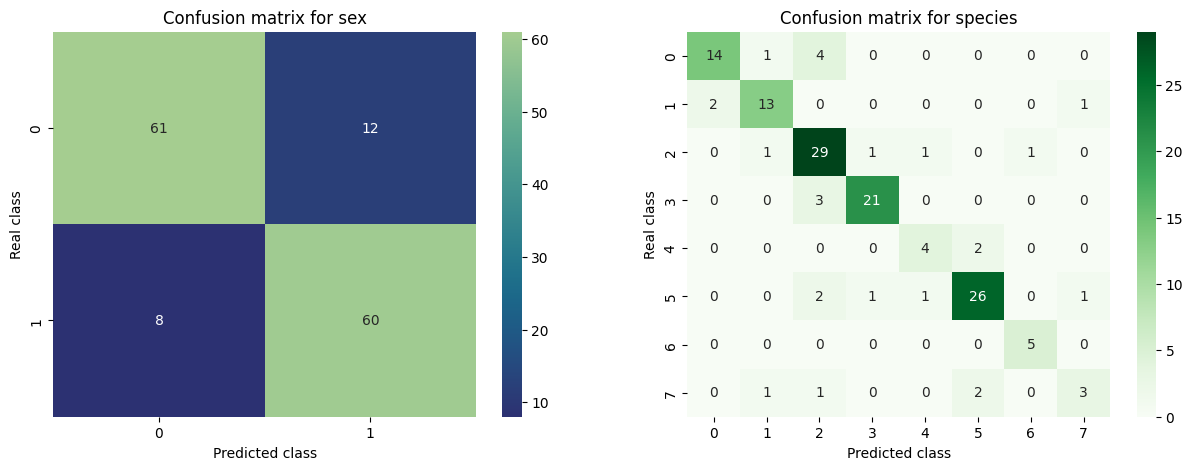

In [ ]:
sex_confusion = confusion_matrix(clf_sex.predict(X_test_sex), y_test_sex)
species_confusion = confusion_matrix(clf_species.predict(X_test_species), y_test_species)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

sns.heatmap(
    data=sex_confusion,
    cmap="crest_r",
    ax=ax1,
    annot=True
)
ax1.set_title("Confusion matrix for sex")
ax1.set_ylabel("Real class")
ax1.set_xlabel("Predicted class")

sns.heatmap(
    data=species_confusion,
    cmap="Greens",
    ax=ax2,
    annot=True
)
ax2.set_title("Confusion matrix for species")
ax2.set_ylabel("Real class")
ax2.set_xlabel("Predicted class")

plt.show()

In [ ]:
print(classification_report(y_test_species, y_pred_species),"\n\n")
print(classification_report(y_test_sex, y_pred_sex))

              precision    recall  f1-score   support

           1       0.74      0.88      0.80        16
           2       0.81      0.81      0.81        16
           3       0.88      0.74      0.81        39
           4       0.88      0.91      0.89        23
           5       0.67      0.67      0.67         6
           6       0.84      0.87      0.85        30
           7       1.00      0.83      0.91         6
           8       0.43      0.60      0.50         5

    accuracy                           0.82       141
   macro avg       0.78      0.79      0.78       141
weighted avg       0.83      0.82      0.82       141
 


              precision    recall  f1-score   support

           1       0.84      0.88      0.86        69
           2       0.88      0.83      0.86        72

    accuracy                           0.86       141
   macro avg       0.86      0.86      0.86       141
weighted avg       0.86      0.86      0.86       141



In [412]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
import pandas as pd
import numpy as np

# --- 1. Подготовка данных (как вы делали для PCA) ---
# Предположим, X - это ваши фичи (все колонки кроме Species_num, Sex_num)
# А y_species - это колонка Species_num
# (Здесь я использую условные имена, замените на свои X и y_species)

# data_dropped = df.drop(columns=["Species_num", "Sex_num"]) # Если у вас так
X = data_dropped.values
y = y_test_species.values # Берем реальные метки видов (нужны числа, а не строки)

# 2. Стандартизация (ОБЯЗАТЕЛЬНА для PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Применяем PCA, сжимаем до 2-х компонент
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- 4. Обучаем Дерево только на PC1 и PC2 ---
# (Ограничим глубину, чтобы график не был слишком сумасшедшим)
tree_pca = DecisionTreeClassifier(max_depth=4) 
tree_pca.fit(X_pca, y)

# --- 5. Отрисовываем границы ---
plt.figure(figsize=(12, 10))

# Эта функция делает всю магию: рисует плоскость, закрашивает зоны и расставляет точки
plot_decision_regions(X_pca, y, clf=tree_pca, legend=2)

# Наводим красоту
plt.xlabel('Главная компонента 1 (PC1)', fontsize=12)
plt.ylabel('Главная компонента 2 (PC2)', fontsize=12)
plt.title('Границы принятия решений Дерева (на основе PCA)', fontsize=15)
plt.show()

ModuleNotFoundError: No module named 'mlxtend'